In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from tabulate import tabulate
from SQUIC_functions import *

In [2]:
accounts = pd.read_csv('accounts.csv')
transactions = pd.read_csv('transactions.csv')

In [3]:
# Create root
balances = {}

# Take users data from account.csv
for _, row in accounts.iterrows():
    acc_id = row["ACCOUNT_ID"] # User id
    open_date = 0
    initial_balance = round(float(row["INIT_BALANCE"]), 2)

    balances[acc_id] = [{"date": open_date,
                         "balance": initial_balance
                        }]
    
    if acc_id == 0: # Check
        print("first user must be 0 => ",str(acc_id))
        print("user 0 initial deposit must be 184.44 => ", initial_balance)

first user must be 0 =>  0
user 0 initial deposit must be 184.44 =>  184.44


In [4]:
# Apply transactions to users' balances
transactions.sort_values(by="TX_ID")

# Track the last balance for each account
current_balances = {acct_id: balances[acct_id][0]["balance"] for acct_id in balances}

for i, (_, row) in enumerate(transactions.iterrows()):
    orig_acct = row["SENDER_ACCOUNT_ID"]
    bene_acct = row["RECEIVER_ACCOUNT_ID"]
    amount = row["TX_AMOUNT"]
    tx_type = row['TX_TYPE']
    date = row["TIMESTAMP"]

    # if i == 0:
    #     print("first transaction must be from 6456 to 9069 => ", orig_acct, bene_acct)
    # if i == 1323233: # check that read till the last transaction
    #     print("\nlast transaction must be from 545 to 2724 => ", orig_acct, bene_acct)

    if orig_acct in balances: # check that sender has a deposit
        last_balance = balances[orig_acct][-1]["balance"] # read balance from balances
        if tx_type in ['TRANSFER', 'WITHDRAWAL']: # all TRANSFER in the csv
            new_balance = last_balance - amount
        # elif tx_type == 'DEPOSIT':
        #    new_balance = last_balance + amount

        balances[orig_acct].append({"date": date, "balance": round(new_balance, 2)})
        # if orig_acct == 1 and date == 1:
        #     print()
        #     print(row['TX_ID'])
        #     print(f"on date {date} user {orig_acct} send to {bene_acct} {amount} dollars")
        #     print(f"user {orig_acct} balance goes from {last_balance} to {new_balance}")
        #     print(balances[orig_acct])
            
    
    if bene_acct in balances: # check that receiver has a deposit
        last_balance = balances[bene_acct][-1]["balance"]
        if tx_type in ['TRANSFER', 'DEPOSIT']:
            new_balance = last_balance + amount
        # elif tx_type == 'WITHDRAWAL':
        #     new_balance = last_balance - amount

        balances[bene_acct].append({"date": date, "balance": round(new_balance, 2)})
        # if bene_acct == 0:
        #     print()
        #     print(row['TX_ID'])
        #     print(f"on date {date} user {orig_acct} send to {bene_acct} {amount} dollars")
        #     print(f"user {bene_acct} balance goes from {last_balance} to {new_balance}")
        #     print(balances[bene_acct])
            

In [5]:
len(balances)

100

In [6]:
for i, (acct_id, account_data) in enumerate(balances.items()):
    if i < 1:
        print(acct_id)
        print(account_data)
        break

0
[{'date': 0, 'balance': 184.44}, {'date': 2, 'balance': 253.63}, {'date': 3, 'balance': 322.82}, {'date': 7, 'balance': 374.37}, {'date': 13, 'balance': 443.56}, {'date': 16, 'balance': 351.34}, {'date': 16, 'balance': 259.12}, {'date': 18, 'balance': 310.67}, {'date': 23, 'balance': 379.86}, {'date': 26, 'balance': 287.64}, {'date': 26, 'balance': 195.42}, {'date': 27, 'balance': 103.2}, {'date': 27, 'balance': 10.98}, {'date': 27, 'balance': 62.53}, {'date': 29, 'balance': -29.69}, {'date': 29, 'balance': -121.91}, {'date': 30, 'balance': -52.72}, {'date': 31, 'balance': 16.47}, {'date': 37, 'balance': -75.75}, {'date': 37, 'balance': -167.97}, {'date': 38, 'balance': -116.42}, {'date': 49, 'balance': -47.23}, {'date': 49, 'balance': -139.45}, {'date': 49, 'balance': -231.67}, {'date': 51, 'balance': -162.48}, {'date': 53, 'balance': -93.29}, {'date': 57, 'balance': -185.51}, {'date': 57, 'balance': -277.73}, {'date': 58, 'balance': -226.18}, {'date': 68, 'balance': -318.4}, {'date

In [7]:
result = []

for date in sorted(set(transactions["TIMESTAMP"])):
    daily_balances = {
        "date": date,
        "balances": {
            str(user): {
                "balance": next((entry["balance"] for entry in reversed(b) if entry["date"] <= date), b[0]["balance"])
            } for user, b in balances.items()}
    }
    result.append(daily_balances)

In [8]:
df = pd.DataFrame(result)

# Unpack 'balances' into separate columns for each user
df = df.join(pd.DataFrame(df['balances'].tolist()))

df.drop('balances', axis=1, inplace=True)
df.set_index('date', inplace=True)
df.drop('_id', axis=1, inplace=True, errors='ignore')

for col in df.columns:
    df[col] = df[col].apply(lambda x: x['balance'] if isinstance(x, dict) else x)

In [9]:
#df = pd.DataFrame([{**entry["balances"], "date": entry["date"]} for entry in data])

#print(df.shape) # must be (720, 1447)
#print(df.head())

#      | id1 | id2 | ... | id1446
# day1 |   
# day2 |        balances
# ...

In [10]:
df

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
date,,,,,,,,,,,,,,,,,,,,,
0,184.44,175.80,142.06,125.89,151.13,140.49,178.38,130.33,147.66,158.34,...,411.76,331.00,340.34,426.02,463.36,411.81,437.84,238.28,386.67,297.29
1,184.44,0.00,142.06,125.89,182.79,140.49,194.34,130.33,163.62,31.70,...,411.76,346.06,356.30,426.02,463.36,411.81,452.90,238.28,386.67,297.29
2,253.63,12.38,142.06,138.27,195.17,217.43,194.34,130.33,163.62,92.89,...,485.33,425.57,356.30,426.02,475.74,578.08,452.90,307.47,416.62,12.55
3,322.82,12.38,142.06,138.27,195.17,217.43,264.42,164.84,163.62,92.89,...,517.69,425.57,356.30,461.13,475.74,647.27,452.90,406.85,551.40,147.33
4,322.82,22.28,198.79,138.27,283.92,76.94,264.42,202.88,163.62,92.89,...,758.87,493.80,137.97,478.19,592.32,702.29,165.99,637.58,681.07,272.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1312.03,-3998.92,-1015.09,-929.73,759.18,175.20,-68.40,131.37,-953.47,-445.13,...,6129.84,2741.40,6605.25,3671.52,1318.73,5914.94,7758.35,9444.49,11741.15,11217.91
196,-1312.03,-3998.92,-1157.14,-929.73,759.18,175.20,-68.40,131.37,-953.47,-445.13,...,6129.84,2754.61,6605.25,3709.68,1318.73,5932.86,7897.52,9457.70,11788.50,11285.84
197,-1312.03,-3998.92,-1299.19,-929.73,639.73,175.20,-68.40,131.37,-953.47,-571.77,...,5823.71,2800.86,6641.93,3833.55,1418.36,5990.27,8095.31,9607.42,11959.72,11468.65


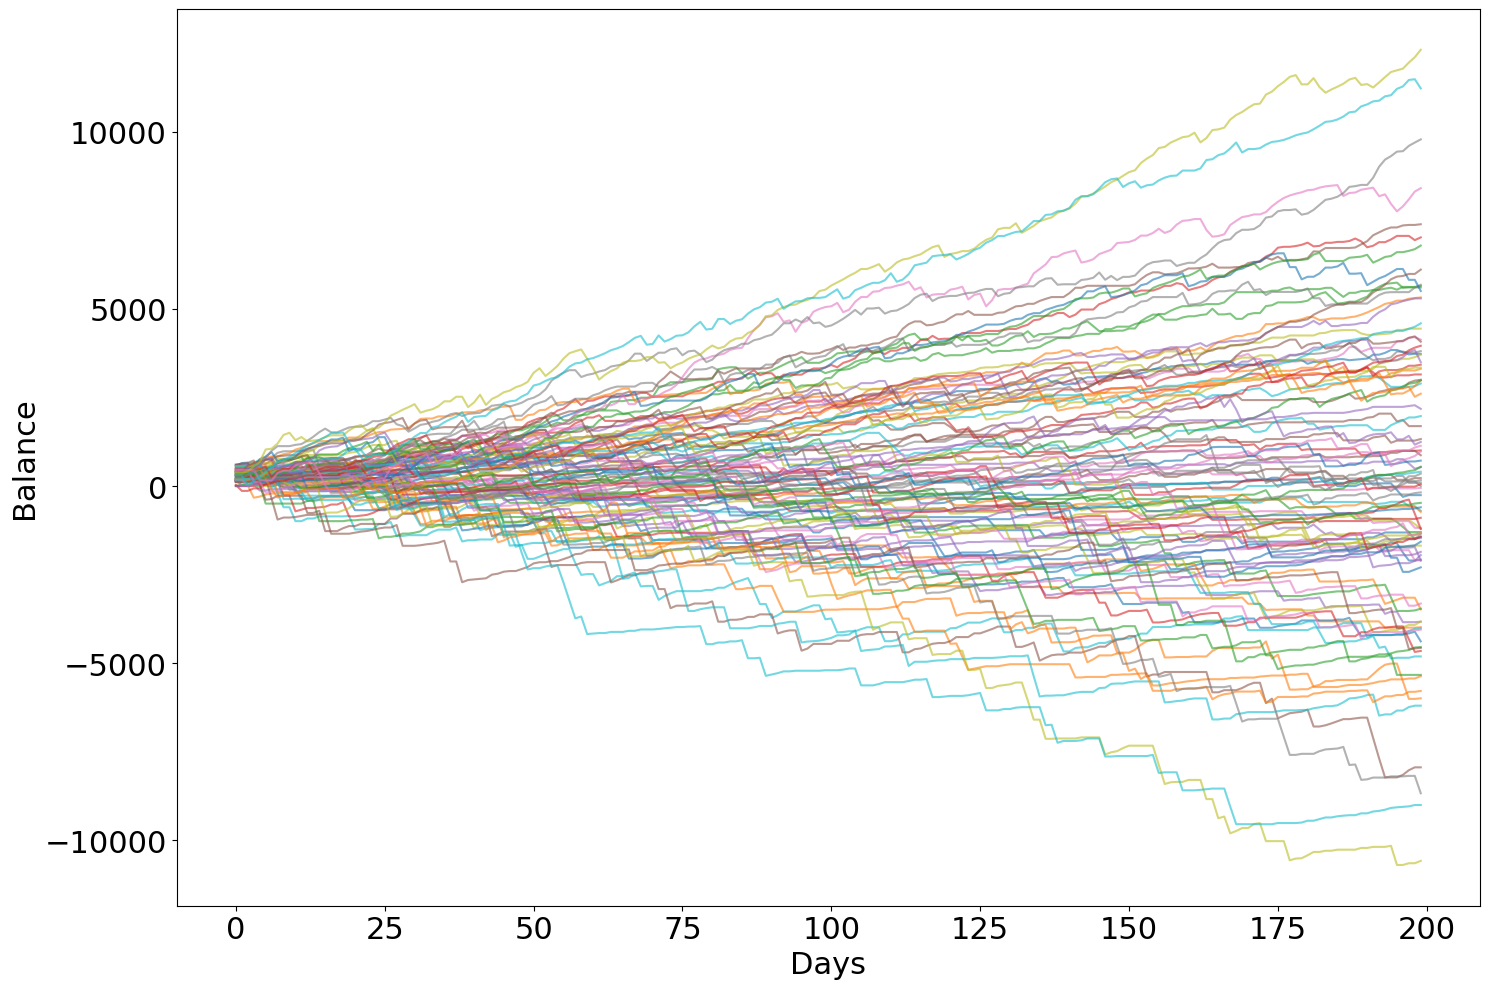

In [11]:
# Plot the balance evolution for all users (columns) as separate lines
# plt.figure(figsize=(15,10), dpi= 300)
plt.figure(figsize=(15,10))

# Plot each column (account balance) as a line
for user in df.columns:
    plt.plot(df.index, df[user], label=f"User {user}", alpha=0.6)

# Add title and labels
# plt.title("Balance Evolution of Users Over Time")
plt.xlabel("Days", fontsize=22)
plt.ylabel("Balance", fontsize=22)

# Rotate x-axis labels for better visibility
#plt.xticks(rotation=45)
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)

# Add legend to differentiate users
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

# Balance Distribution

### First and last day

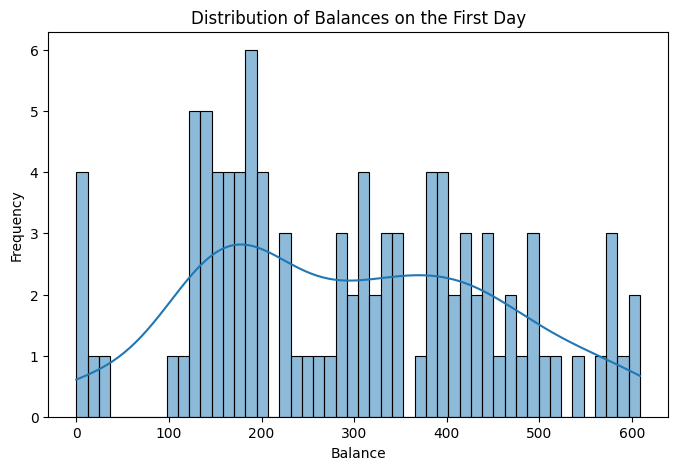

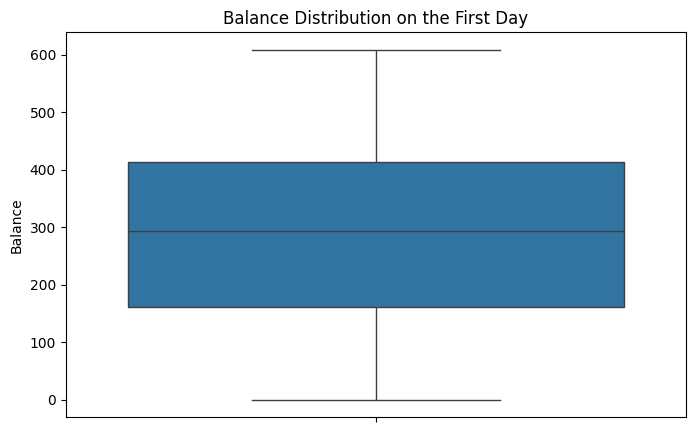

In [12]:
# Select the balances on the first day
first_day_balances = df.iloc[0]

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(first_day_balances, bins=50, kde=True)
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.title("Distribution of Balances on the First Day")
plt.show()

# Plot box plot
plt.figure(figsize=(8, 5))
sns.boxplot(y=first_day_balances)
plt.ylabel("Balance")
plt.title("Balance Distribution on the First Day")
plt.show()

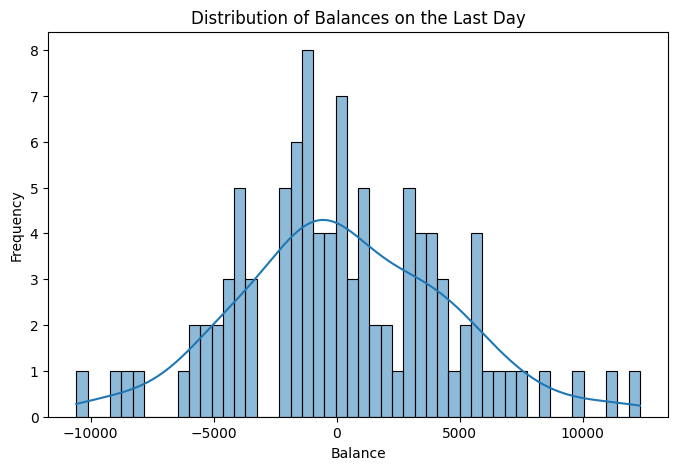

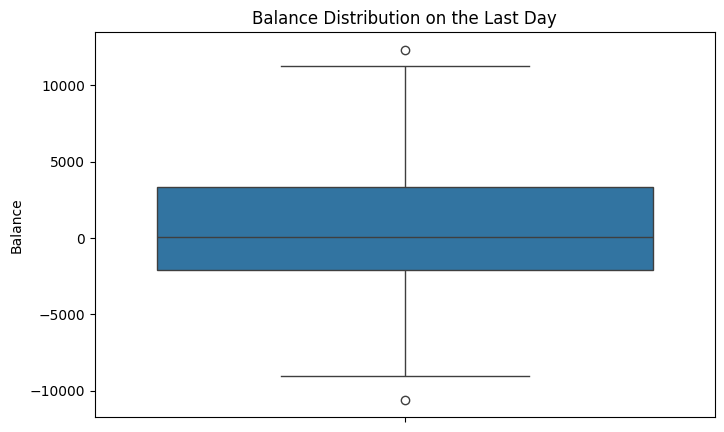

In [13]:
# Select the balances on the first day
last_day_balances = df.iloc[-1]

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(last_day_balances, bins=50, kde=True)
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.title("Distribution of Balances on the Last Day")
plt.show()

# Plot box plot
plt.figure(figsize=(8, 5))
sns.boxplot(y=last_day_balances)
plt.ylabel("Balance")
plt.title("Balance Distribution on the Last Day")
plt.show()

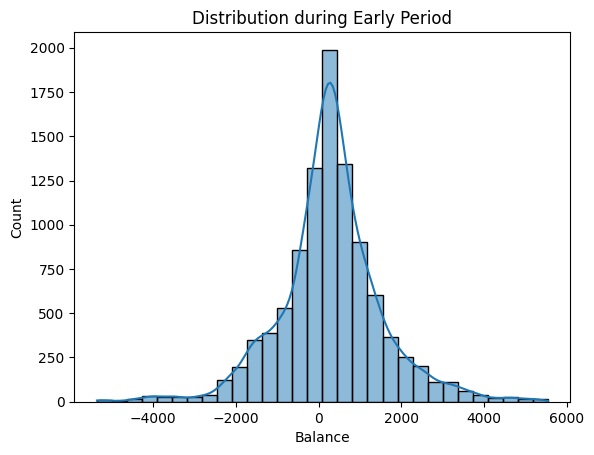

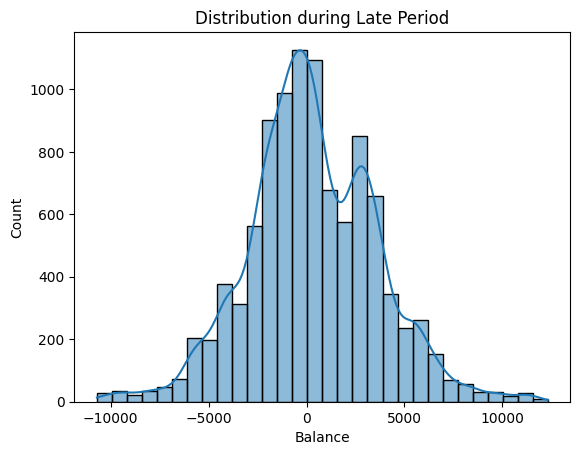

In [14]:
# Split the DataFrame into two parts
early_period = df.iloc[:int(0.5 * len(df))]
late_period  = df.iloc[int(0.5 * len(df)):]

# Plot distribution for early days (aggregated over users and days)
sns.histplot(early_period.values.flatten(), bins=30, kde=True)
plt.title("Distribution during Early Period")
plt.xlabel("Balance")
plt.show()

# Plot distribution for late days
sns.histplot(late_period.values.flatten(), bins=30, kde=True)
plt.title("Distribution during Late Period")
plt.xlabel("Balance")
plt.show()

### Total Distribution

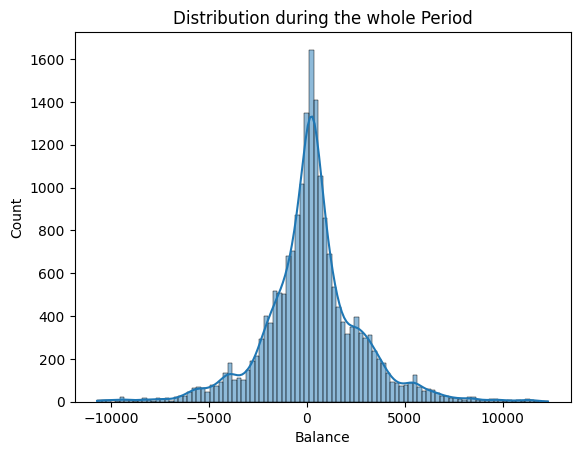

In [15]:
values_df = df.values.flatten()
# Plot distribution for all the days (aggregated over users and days)
sns.histplot(values_df, bins=100, kde=True)
plt.title("Distribution during the whole Period")
plt.xlabel("Balance")
plt.show()

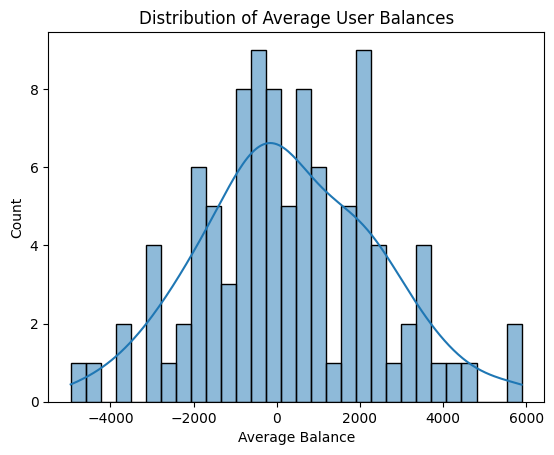

In [16]:
# Compute the mean balance per user over all days
user_means = df.mean(axis=0)

sns.histplot(user_means, bins=30, kde=True)
plt.title("Distribution of Average User Balances")
plt.xlabel("Average Balance")
plt.show()

# Squic

In [17]:
df.T

date,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,184.44,184.44,253.63,322.82,322.82,322.82,322.82,374.37,374.37,374.37,...,-1450.41,-1450.41,-1381.22,-1312.03,-1312.03,-1312.03,-1312.03,-1312.03,-1496.47,-1427.28
1,175.80,0.00,12.38,12.38,22.28,22.28,32.18,32.18,32.18,32.18,...,-3823.12,-3823.12,-3823.12,-3998.92,-3998.92,-3998.92,-3998.92,-3998.92,-3998.92,-3986.54
2,142.06,142.06,142.06,142.06,198.79,56.74,66.64,66.64,-28.58,-28.58,...,-919.87,-919.87,-919.87,-919.87,-919.87,-1015.09,-1157.14,-1299.19,-1299.19,-1299.19
3,125.89,125.89,138.27,138.27,138.27,138.27,138.27,138.27,178.23,218.19,...,-989.31,-929.73,-929.73,-929.73,-929.73,-929.73,-929.73,-929.73,-929.73,-897.73
4,151.13,182.79,195.17,195.17,283.92,204.50,204.50,204.50,204.50,236.16,...,638.77,687.49,687.49,687.49,687.49,759.18,759.18,639.73,488.62,532.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,411.81,411.81,578.08,647.27,702.29,738.97,738.97,839.29,855.04,870.79,...,5302.29,5467.55,5565.16,5685.16,5838.99,5914.94,5932.86,5990.27,5990.27,6112.25
96,437.84,452.90,452.90,452.90,165.99,159.13,159.13,369.29,433.40,433.40,...,8397.31,8426.50,8186.50,8237.63,7969.31,7758.35,7897.52,8095.31,8317.07,8411.27
97,238.28,238.28,307.47,406.85,637.58,807.53,997.13,1126.93,1126.93,1126.93,...,8504.86,8706.56,9016.88,9218.89,9317.82,9444.49,9457.70,9607.42,9701.23,9790.04
98,386.67,386.67,416.62,551.40,681.07,1032.70,1054.83,1201.22,1443.05,1505.01,...,11352.51,11255.45,11399.45,11549.06,11693.80,11741.15,11788.50,11959.72,12111.11,12321.77


In [18]:
ROWS = len(df.iloc[0])
ROWS

100

## Squic DF

### Non normalized

In [19]:
# Y = df.T.to_numpy()  # Transpose to get shape (users, days)

In [20]:
# squic_dict = {}

In [21]:
# l = [1e5, 3e5, 5e5, 7e5, 9e5, 11e5, 13e5, 15e5, 17e5, 19e5]

In [22]:
# data_nnz = []
# data_nnzr = []
# data_time = []
# data_sym = []

# for rho in l:
#     X, computation_time = compute_squic(Y, rho)
#     computation_time = round(computation_time, 2)
#     squic_dict[rho] = X
#     print(f"time required: {computation_time} seconds")

#     nonz, nonz_r = count_nnz(squic_dict[rho], ROWS)

#     if is_symmetric(squic_dict[rho]):
#         print(f"✅ Matrix is symmetric per rho {rho}")
#         data_sym.append('Yes')
#     else:
#         print(f"❌ Matrix is not symmetric per rho {rho}")
#         data_sym.append('No')

#     data_nnz.append(nonz)
#     data_nnzr.append(nonz_r)
#     data_time.append(computation_time)

#     if nonz == ROWS:
#         print(f"For rho = {rho} just element on the diagonal")
#         sparsity_pattern(squic_dict[rho])
#     elif nonz == ROWS * ROWS:
#         print(f"For rho = {rho} big dense matrix")
#         # sparsity_pattern(squic_dict[rho])
#         print(f"nnz = {nonz}")
#         print(f"nnz/row = {nonz_r}")
#     else:
#         print(f"For rho = {rho} there are some nnz")
#         # sparsity_pattern(squic_dict[rho])
#         print(f"nnz = {nonz}")
#         print(f"nnz/row = {nonz_r}")
        

# table_squic = [
#     ["NNZ"] + data_nnz,
#     ["NNZ/Row"] + data_nnzr,
#     ["Time (s)"] + data_time,
#     ["Symmetric"] + data_sym
# ]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=1.20e-02 nnz(S)/p=7.83e+01
* iter=1 time=1.33e-02 obj=9.12e+07 |delta(obj)|/obj=9.29e-01 nnz(X,L,W)/p=[7.83e+01 4.18e+01 1.02e+00] lns_iter=29 
* iter=2 time=4.58e-03 obj=4.89e+07 |delta(obj)|/obj=8.67e-01 nnz(X,L,W)/p=[7.83e+01 4.18e+01 6.11e+01] lns_iter=30 
* iter=3 time=1.84e-02 obj=3.32e+07 |delta(obj)|/

ValueError: too many values to unpack (expected 2)

### Normalization

In [23]:
squic_norm_dict = {}

In [24]:
Y = df.T.to_numpy()
# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

In [25]:
print(Y.shape)
print(Y_new.shape)

(100, 200)
(100, 200)


In [28]:
l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2, 5e-2, 1e-2, 9e-3, 5e-3, 1e-3, 1e-4]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.51e-04 nnz(S)/p=3.68e+01
* iter=1 time=1.35e-03 obj=1.72e+02 |delta(obj)|/obj=4.20e-01 nnz(X,L,W)/p=[3.68e+01 2.19e+01 3.13e+01] lns_iter=3 
* iter=2 time=3.37e-03 obj=1.69e+02 |delta(obj)|/obj=2.30e-02 nnz(X,L,W)/p=[3.68e+01 2.19e+01 5.35e+01] lns_iter=1 
* iter=3 time=7.13e-03 obj=1.66e+02 |delta(obj)|/ob

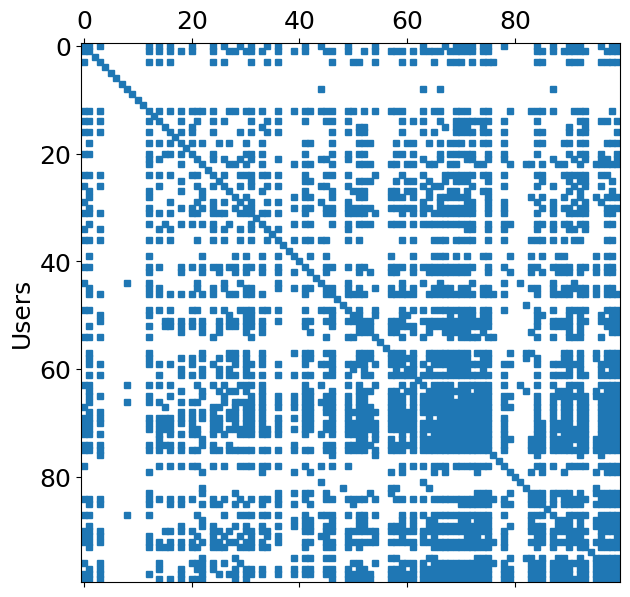

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.61e-04 nnz(S)/p=7.40e+01
* iter=1 time=3.12e-03 obj=1.26e+02 |delta(obj)|/obj=2.08e-01 nnz(X,L,W)/p=[7.40e+01 4.21e+01 7.58e+01] lns_iter=6 
* iter=2 time=1.25e-02 obj=1.25e+02 |delta(obj)|/obj=9.42e-03 nnz(X,L,W)/p=[7.71e+01 4.09e+01 9.75e+01] lns_iter=1 
* iter=3 time=2.59e-02 obj=1.24e+02 |delta(obj)|/ob

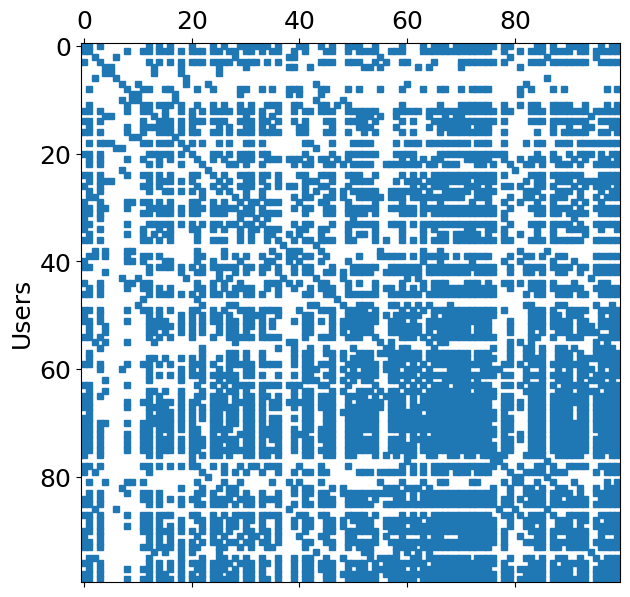

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.25e-04 nnz(S)/p=8.93e+01
* iter=1 time=2.21e-03 obj=7.01e+01 |delta(obj)|/obj=4.26e-01 nnz(X,L,W)/p=[8.93e+01 4.92e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.21e-03 obj=6.63e+01 |delta(obj)|/obj=5.72e-02 nnz(X,L,W)/p=[8.93e+01 4.92e+01 9.41e+01] lns_iter=10 
* iter=3 time=2.56e-02 obj=6.01e+01 |delta(obj)|/o

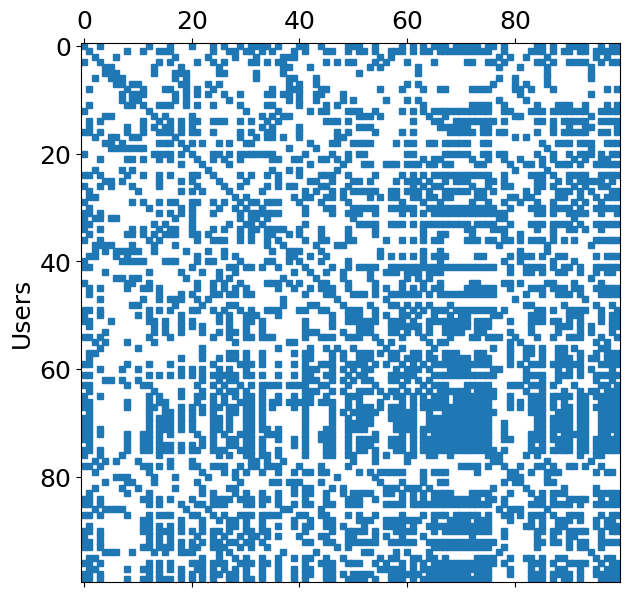

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.17e-04 nnz(S)/p=9.44e+01
* iter=1 time=2.44e-03 obj=7.61e+01 |delta(obj)|/obj=3.14e-01 nnz(X,L,W)/p=[9.44e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.37e-03 obj=5.98e+01 |delta(obj)|/obj=2.73e-01 nnz(X,L,W)/p=[9.44e+01 5.00e+01 9.15e+01] lns_iter=9 
* iter=3 time=2.79e-02 obj=4.32e+01 |delta(obj)|/ob

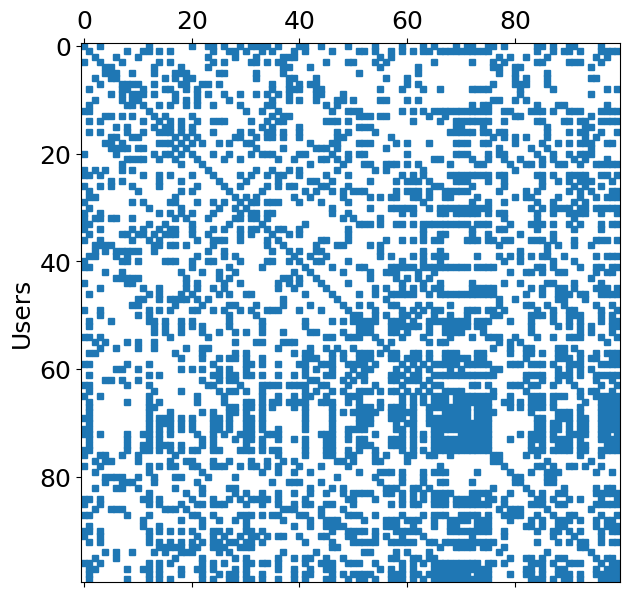

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.37e-04 nnz(S)/p=9.48e+01
* iter=1 time=2.72e-03 obj=7.42e+01 |delta(obj)|/obj=3.48e-01 nnz(X,L,W)/p=[9.48e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.46e-03 obj=5.74e+01 |delta(obj)|/obj=2.92e-01 nnz(X,L,W)/p=[9.48e+01 5.00e+01 9.17e+01] lns_iter=9 
* iter=3 time=2.91e-02 obj=4.14e+01 |delta(obj)|/ob

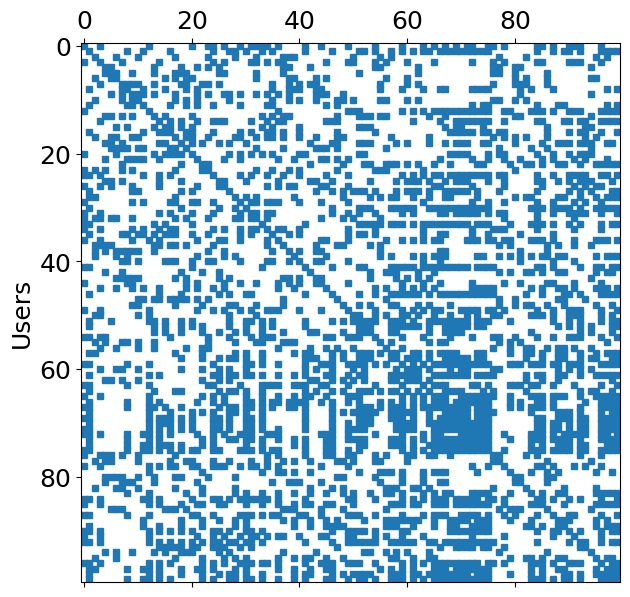

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.34e-04 nnz(S)/p=9.68e+01
* iter=1 time=2.56e-03 obj=6.63e+01 |delta(obj)|/obj=5.07e-01 nnz(X,L,W)/p=[9.68e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.48e-03 obj=4.78e+01 |delta(obj)|/obj=3.87e-01 nnz(X,L,W)/p=[9.68e+01 5.00e+01 9.20e+01] lns_iter=9 
* iter=3 time=2.88e-02 obj=3.28e+01 |delta(obj)|/ob

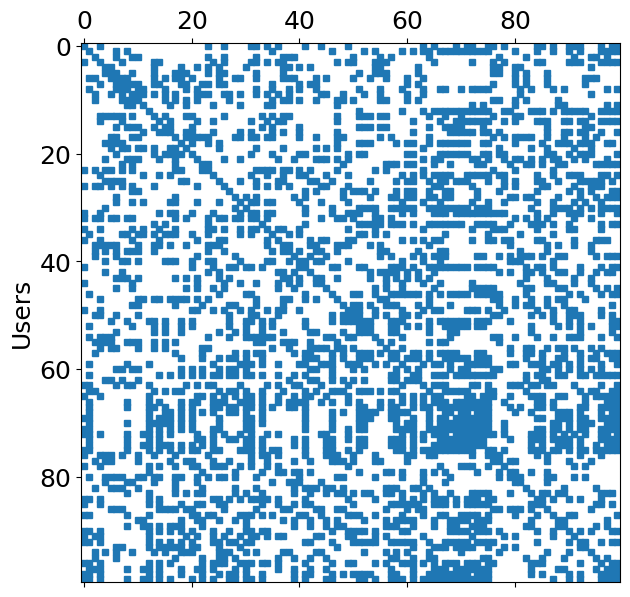

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.71e-04 nnz(S)/p=9.94e+01
* iter=1 time=2.73e-03 obj=5.83e+01 |delta(obj)|/obj=7.16e-01 nnz(X,L,W)/p=[9.94e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.76e-03 obj=3.79e+01 |delta(obj)|/obj=5.36e-01 nnz(X,L,W)/p=[9.94e+01 5.00e+01 9.30e+01] lns_iter=9 
* iter=3 time=3.03e-02 obj=2.43e+01 |delta(obj)|/ob

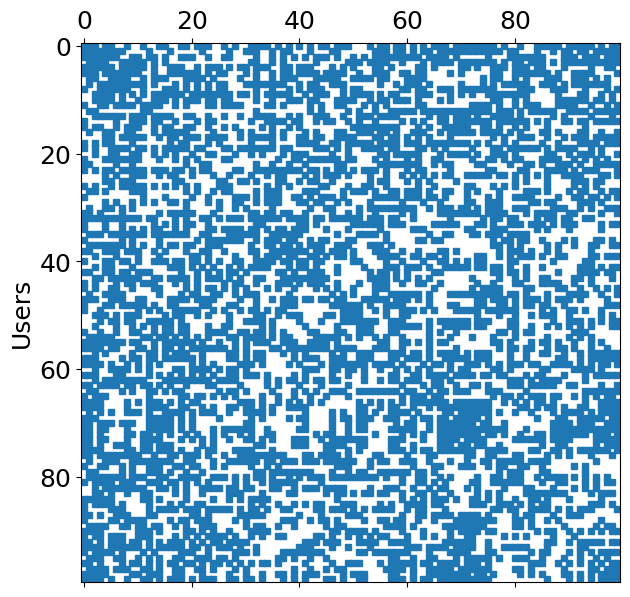

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.99e-04 nnz(S)/p=9.95e+01
* iter=1 time=2.75e-03 obj=5.81e+01 |delta(obj)|/obj=7.22e-01 nnz(X,L,W)/p=[9.95e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.45e-03 obj=3.77e+01 |delta(obj)|/obj=5.40e-01 nnz(X,L,W)/p=[9.95e+01 5.00e+01 9.30e+01] lns_iter=9 
* iter=3 time=2.99e-02 obj=2.39e+01 |delta(obj)|/ob

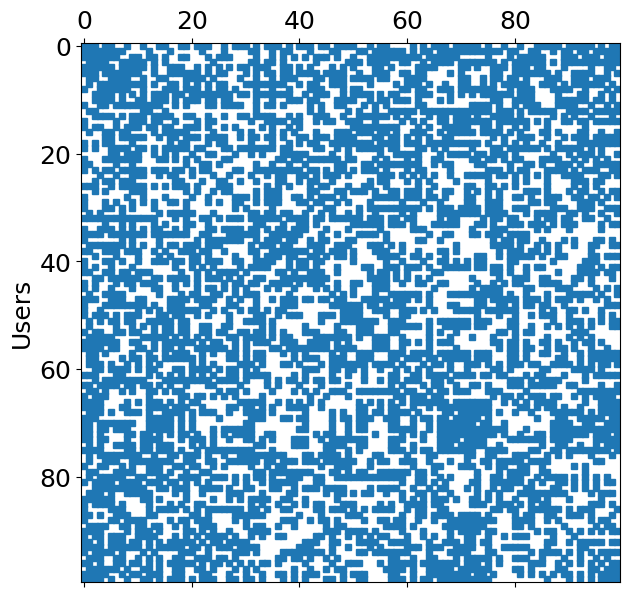

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.80e-04 nnz(S)/p=9.97e+01
* iter=1 time=2.47e-03 obj=5.72e+01 |delta(obj)|/obj=7.47e-01 nnz(X,L,W)/p=[9.97e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.43e-03 obj=3.67e+01 |delta(obj)|/obj=5.60e-01 nnz(X,L,W)/p=[9.97e+01 5.00e+01 9.30e+01] lns_iter=9 
* iter=3 time=2.98e-02 obj=2.32e+01 |delta(obj)|/ob

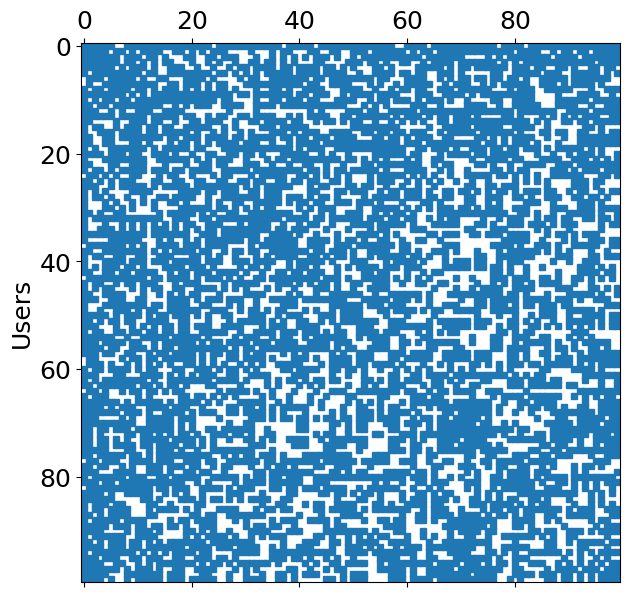

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.59e-04 nnz(S)/p=1.00e+02
* iter=1 time=2.50e-03 obj=5.64e+01 |delta(obj)|/obj=7.72e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.98e-03 obj=3.57e+01 |delta(obj)|/obj=5.81e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 9.31e+01] lns_iter=9 
* iter=3 time=2.98e-02 obj=2.22e+01 |delta(obj)|/ob

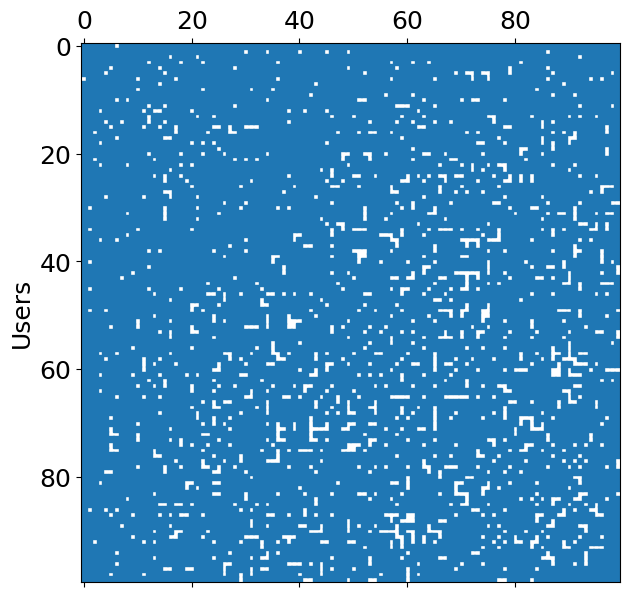

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-04 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.61e-04 nnz(S)/p=1.00e+02
* iter=1 time=2.40e-03 obj=5.62e+01 |delta(obj)|/obj=7.78e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.44e-03 obj=3.55e+01 |delta(obj)|/obj=5.86e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 9.31e+01] lns_iter=9 
* iter=3 time=3.00e-02 obj=2.20e+01 |delta(obj)|/ob

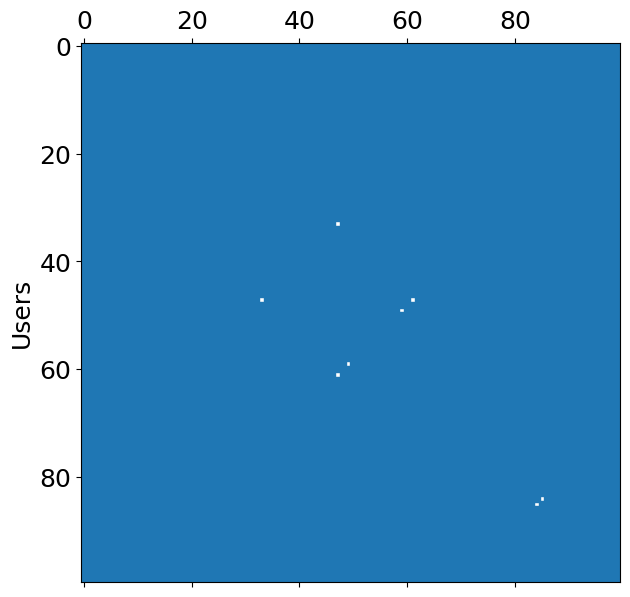

In [29]:
data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    X, computation_time = compute_squic(Y_new, rho)
    computation_time = round(computation_time, 2)
    squic_norm_dict[rho] = X
    print(f"time required: {computation_time} seconds")

    nonz, nonz_r = count_nnz(squic_norm_dict[rho], ROWS)

    if is_symmetric(squic_norm_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append('Yes')
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append('No')

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(computation_time)

    if nonz == ROWS:
        print(f"For rho = {rho} just element on the diagonal")
        sparsity_pattern(squic_norm_dict[rho])
    elif nonz == ROWS * ROWS:
        print(f"For rho = {rho} big dense matrix")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        sparsity_pattern(squic_norm_dict[rho])
    else:
        print(f"For rho = {rho} there are some nnz")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        sparsity_pattern(squic_norm_dict[rho])


table_squic_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]

## Squic-FIT

### Non normalized

In [30]:
fit_dict = {}

In [31]:
Y = df.T.to_numpy()  # Convert to (users, days)

In [32]:
l = [1e5, 3e5, 5e5, 7e5, 9e5, 11e5, 13e5, 15e5, 17e5, 19e5]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.95e-04 nnz(S)/p=7.83e+01
* iter=1 time=2.69e-03 obj=9.12e+07 |delta(obj)|/obj=9.29e-01 nnz(X,L,W)/p=[7.83e+01 4.18e+01 1.02e+00] lns_iter=29 
* iter=2 time=4.34e-03 obj=4.89e+07 |delta(obj)|/obj=8.67e-01 nnz(X,L,W)/p=[7.83e+01 4.18e+01 6.11e+01] lns_iter=30 
* iter=3 time=1.87e-02 obj=3.32e+07 |delta(obj)|/

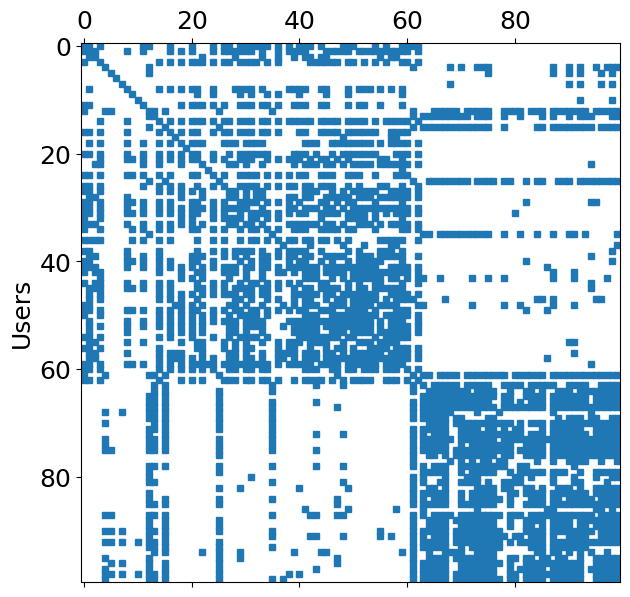

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      3.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.31e-04 nnz(S)/p=6.24e+01
* iter=1 time=3.31e-03 obj=1.23e+08 |delta(obj)|/obj=4.25e-01 nnz(X,L,W)/p=[6.24e+01 3.43e+01 1.00e+00] lns_iter=29 
* iter=2 time=4.41e-03 obj=8.58e+07 |delta(obj)|/obj=4.40e-01 nnz(X,L,W)/p=[6.24e+01 3.43e+01 5.73e+01] lns_iter=30 
* iter=3 time=1.46e-02 obj=5.87e+07 |delta(obj)|/

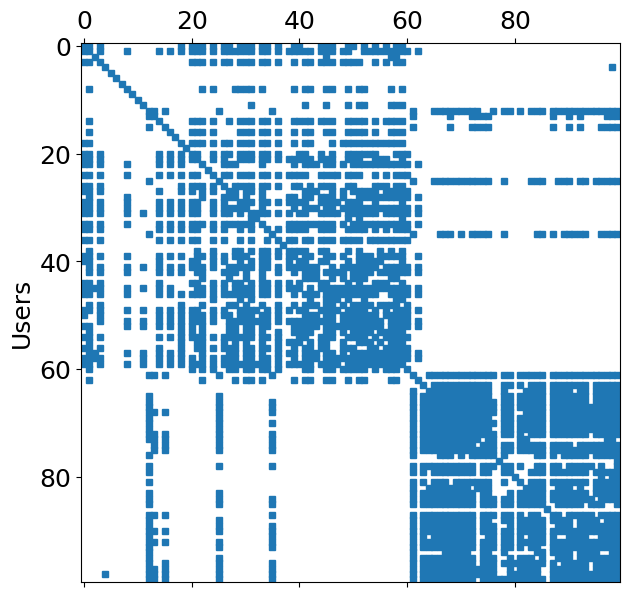

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.26e-04 nnz(S)/p=5.18e+01
* iter=1 time=2.37e-03 obj=1.54e+08 |delta(obj)|/obj=1.44e-01 nnz(X,L,W)/p=[5.18e+01 2.85e+01 1.00e+00] lns_iter=29 
* iter=2 time=3.50e-03 obj=8.76e+07 |delta(obj)|/obj=7.56e-01 nnz(X,L,W)/p=[5.18e+01 2.85e+01 7.03e+01] lns_iter=29 
* iter=3 time=1.33e-02 obj=8.57e+07 |delta(obj)|/

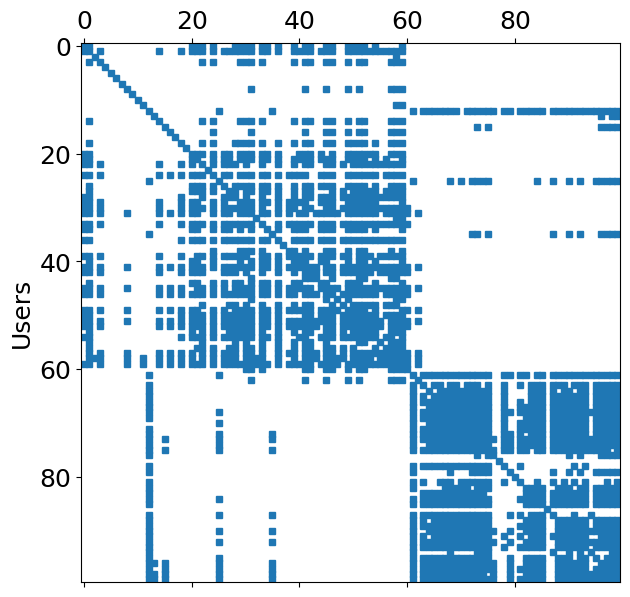

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      7.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.59e-04 nnz(S)/p=4.33e+01
* iter=1 time=2.11e-03 obj=1.20e+08 |delta(obj)|/obj=4.71e-01 nnz(X,L,W)/p=[4.33e+01 2.40e+01 2.67e+01] lns_iter=28 
* iter=2 time=4.92e-03 obj=1.18e+08 |delta(obj)|/obj=1.15e-02 nnz(X,L,W)/p=[4.33e+01 2.40e+01 5.70e+01] lns_iter=28 
* iter=3 time=1.06e-02 obj=1.17e+08 |delta(obj)|/

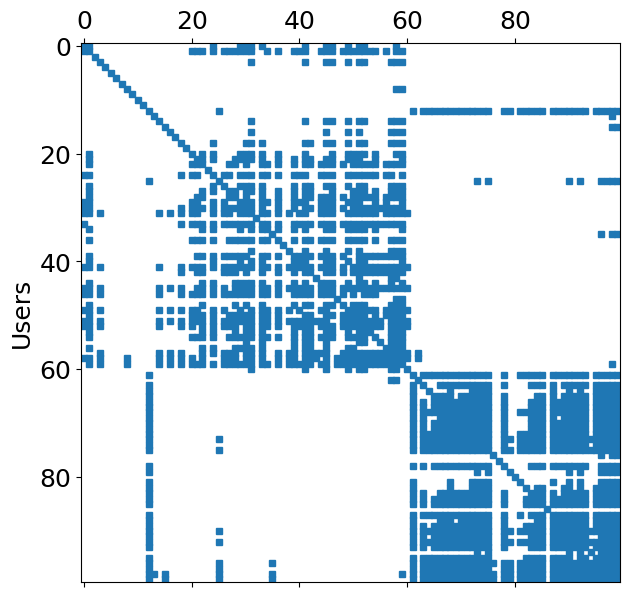

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.92e-04 nnz(S)/p=3.65e+01
* iter=1 time=1.83e-03 obj=1.55e+08 |delta(obj)|/obj=1.36e-01 nnz(X,L,W)/p=[3.65e+01 2.02e+01 1.01e+01] lns_iter=28 
* iter=2 time=3.40e-03 obj=1.45e+08 |delta(obj)|/obj=6.60e-02 nnz(X,L,W)/p=[3.65e+01 2.02e+01 6.25e+01] lns_iter=27 
* iter=3 time=8.91e-03 obj=1.43e+08 |delta(obj)|/

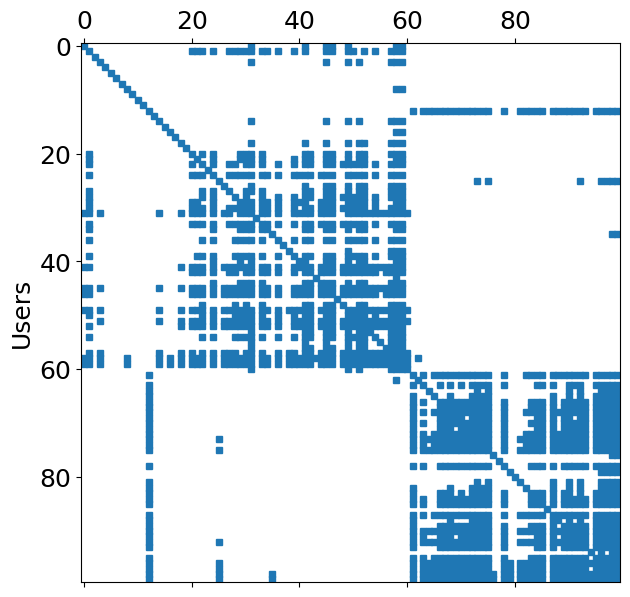

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.100000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.51e-04 nnz(S)/p=3.08e+01
* iter=1 time=1.64e-03 obj=1.88e+08 |delta(obj)|/obj=6.44e-02 nnz(X,L,W)/p=[3.08e+01 1.70e+01 5.12e+00] lns_iter=28 
* iter=2 time=2.94e-03 obj=1.71e+08 |delta(obj)|/obj=1.03e-01 nnz(X,L,W)/p=[3.08e+01 1.70e+01 5.95e+01] lns_iter=27 
* iter=3 time=8.07e-03 obj=1.70e+08 |delta(obj)|/

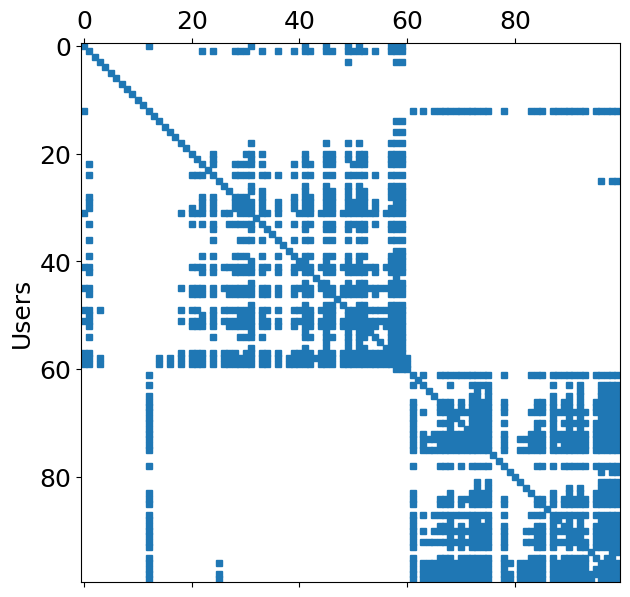

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.300000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.36e-04 nnz(S)/p=2.63e+01
* iter=1 time=1.63e-03 obj=2.20e+08 |delta(obj)|/obj=1.98e-01 nnz(X,L,W)/p=[2.63e+01 1.51e+01 3.34e+00] lns_iter=28 
* iter=2 time=2.58e-03 obj=2.05e+08 |delta(obj)|/obj=7.31e-02 nnz(X,L,W)/p=[2.63e+01 1.51e+01 4.85e+01] lns_iter=28 
* iter=3 time=6.49e-03 obj=2.00e+08 |delta(obj)|/

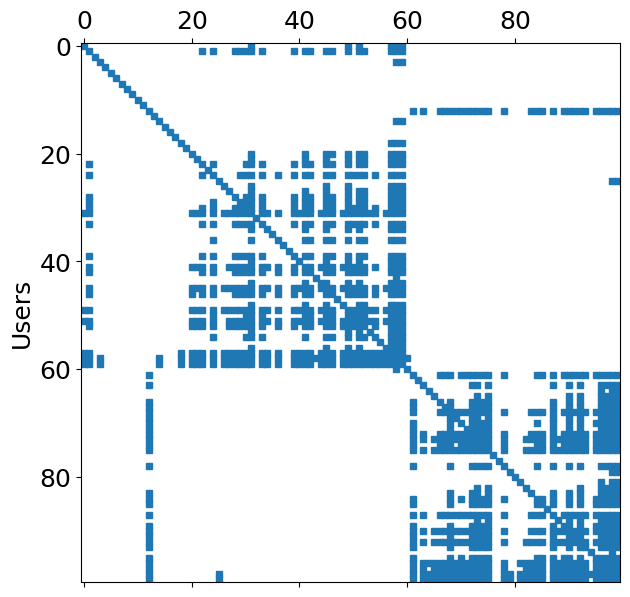

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.500000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.73e-04 nnz(S)/p=2.24e+01
* iter=1 time=1.40e-03 obj=2.49e+08 |delta(obj)|/obj=2.94e-01 nnz(X,L,W)/p=[2.24e+01 1.33e+01 2.38e+00] lns_iter=28 
* iter=2 time=2.14e-03 obj=2.29e+08 |delta(obj)|/obj=8.72e-02 nnz(X,L,W)/p=[2.24e+01 1.33e+01 4.31e+01] lns_iter=28 
* iter=3 time=5.26e-03 obj=2.23e+08 |delta(obj)|/

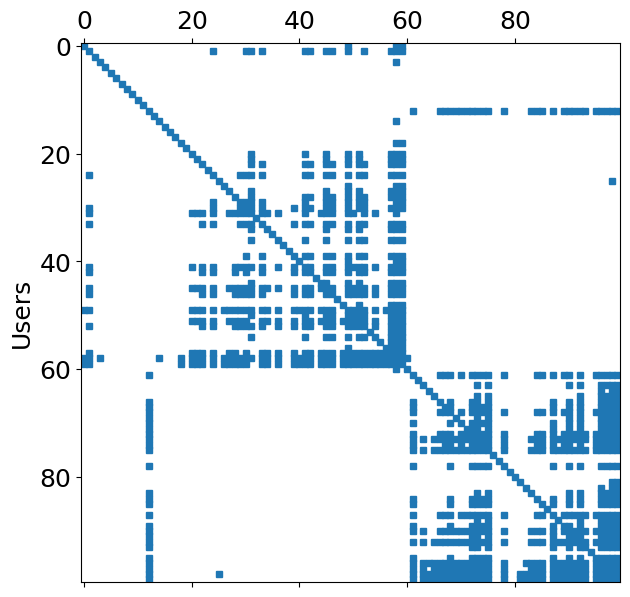

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.700000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.75e-04 nnz(S)/p=1.94e+01
* iter=1 time=1.45e-03 obj=2.78e+08 |delta(obj)|/obj=3.67e-01 nnz(X,L,W)/p=[1.94e+01 1.14e+01 1.94e+00] lns_iter=28 
* iter=2 time=2.12e-03 obj=2.54e+08 |delta(obj)|/obj=9.37e-02 nnz(X,L,W)/p=[1.94e+01 1.14e+01 3.87e+01] lns_iter=28 
* iter=3 time=4.97e-03 obj=2.49e+08 |delta(obj)|/

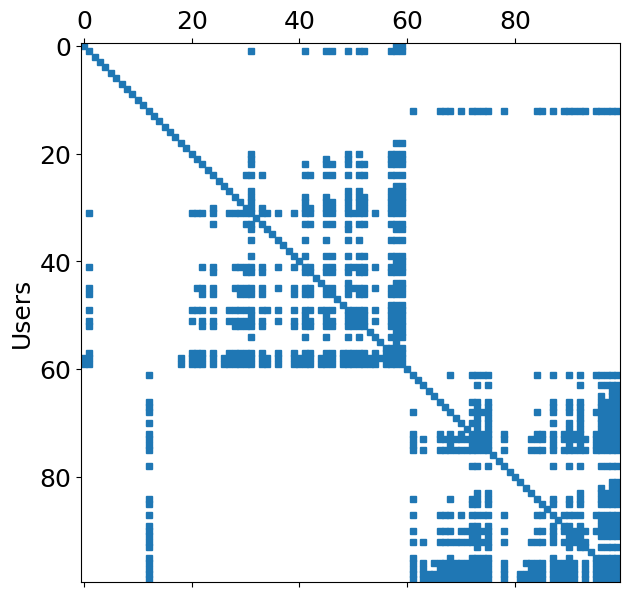

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.900000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.49e-04 nnz(S)/p=1.68e+01
* iter=1 time=1.35e-03 obj=3.06e+08 |delta(obj)|/obj=4.24e-01 nnz(X,L,W)/p=[1.68e+01 9.91e+00 1.52e+00] lns_iter=28 
* iter=2 time=1.94e-03 obj=2.78e+08 |delta(obj)|/obj=1.01e-01 nnz(X,L,W)/p=[1.68e+01 9.91e+00 3.52e+01] lns_iter=28 
* iter=3 time=4.75e-03 obj=2.74e+08 |delta(obj)|/

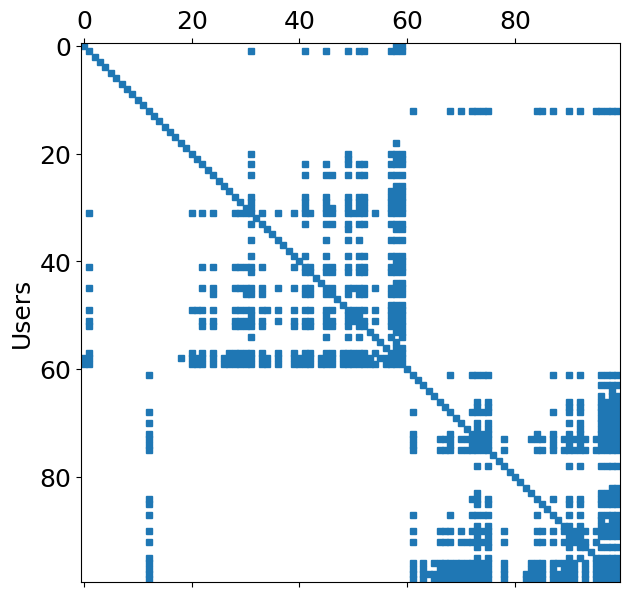

In [33]:
data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    fit_dict[rho], end_time = squic_fit(Y, lambda_val=rho, eta=rho * 0.1)
    end_time = round(end_time, 2)
    print(f"required time: {end_time}")

    nnz, nnz_r = nnz_fit(fit_dict[rho], ROWS)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    if is_symmetric(fit_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append("Yes")
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append("No")

    sparsity_pattern(fit_dict[rho])

    data_nnz.append(nnz)
    data_nnzr.append(nnz_r)
    data_time.append(end_time)

table_fit = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]

### Normalization

In [34]:
l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2, 5e-2, 1e-2, 9e-3, 5e-3, 1e-3, 1e-4]

In [35]:
fit_norm_dict = {}

In [36]:
# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

In [37]:
len(Y_new)

100

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.81e-04 nnz(S)/p=3.68e+01
* iter=1 time=1.41e-03 obj=1.72e+02 |delta(obj)|/obj=4.20e-01 nnz(X,L,W)/p=[3.68e+01 2.19e+01 3.13e+01] lns_iter=3 
* iter=2 time=3.41e-03 obj=1.69e+02 |delta(obj)|/obj=2.30e-02 nnz(X,L,W)/p=[3.68e+01 2.19e+01 5.35e+01] lns_iter=1 
* iter=3 time=7.20e-03 obj=1.66e+02 |delta(obj)|/ob

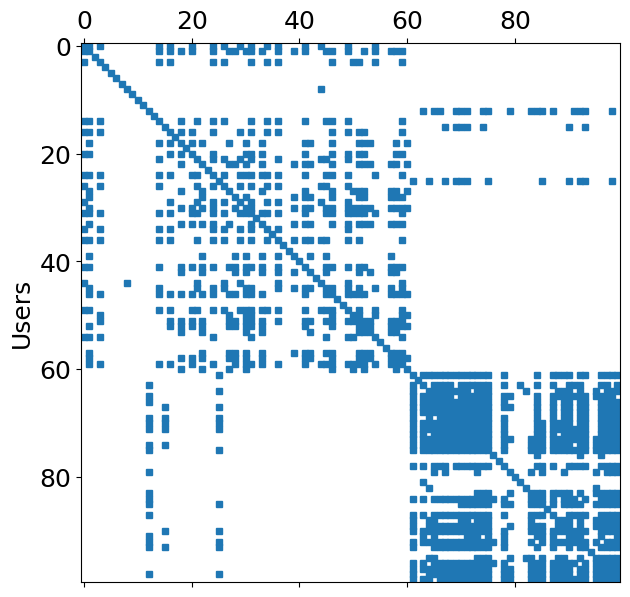

✅ Matrix is symmetric per rho 0.9
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.03e-04 nnz(S)/p=7.40e+01
* iter=1 time=1.98e-03 obj=1.26e+02 |delta(obj)|/obj=2.08e-01 nnz(X,L,W)/p=[7.40e+01 4.21e+01 7.58e+01] lns_iter=6 
* iter=2 time=1.04e-02 obj=1.25e+02 |delta(obj)|/obj=9.42e-03 nnz(X,L,W)/p=[7.71e+01 4.09e+01 9.75e+01] lns_iter=1 
* iter=3 time=2.5

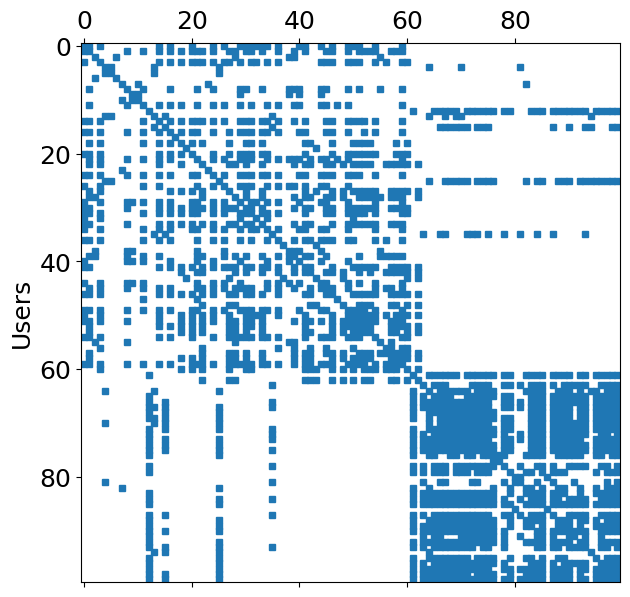

✅ Matrix is symmetric per rho 0.5
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.45e-04 nnz(S)/p=8.93e+01
* iter=1 time=2.29e-03 obj=7.01e+01 |delta(obj)|/obj=4.26e-01 nnz(X,L,W)/p=[8.93e+01 4.92e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.36e-03 obj=6.63e+01 |delta(obj)|/obj=5.72e-02 nnz(X,L,W)/p=[8.93e+01 4.92e+01 9.41e+01] lns_iter=10 
* iter=3 time=2.

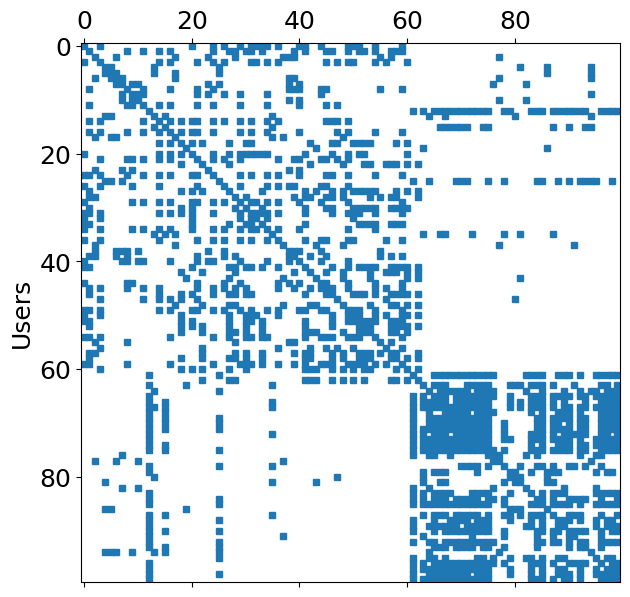

✅ Matrix is symmetric per rho 0.2
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.60e-04 nnz(S)/p=9.44e+01
* iter=1 time=2.50e-03 obj=7.61e+01 |delta(obj)|/obj=3.14e-01 nnz(X,L,W)/p=[9.44e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.30e-03 obj=5.98e+01 |delta(obj)|/obj=2.73e-01 nnz(X,L,W)/p=[9.44e+01 5.00e+01 9.15e+01] lns_iter=9 
* iter=3 time=2.7

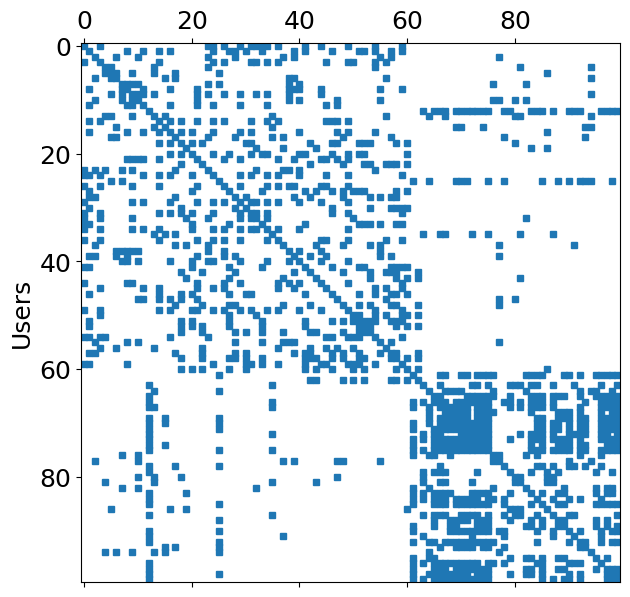

✅ Matrix is symmetric per rho 0.1
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.88e-04 nnz(S)/p=9.48e+01
* iter=1 time=2.46e-03 obj=7.42e+01 |delta(obj)|/obj=3.48e-01 nnz(X,L,W)/p=[9.48e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.32e-03 obj=5.74e+01 |delta(obj)|/obj=2.92e-01 nnz(X,L,W)/p=[9.48e+01 5.00e+01 9.17e+01] lns_iter=9 
* iter=3 time=4.1

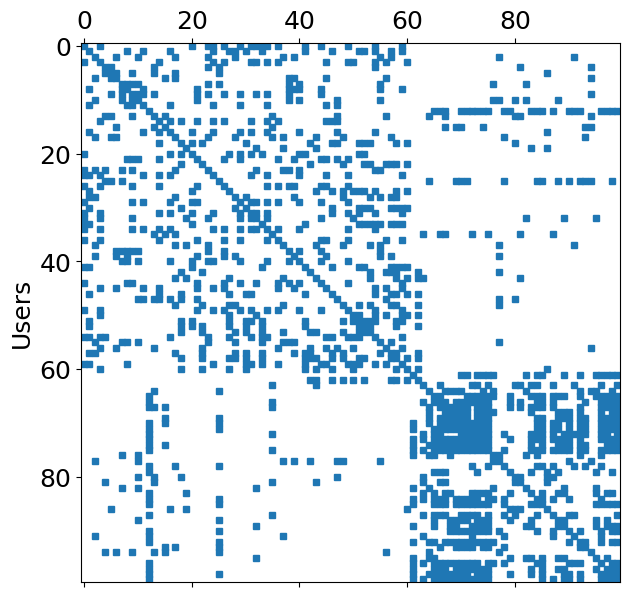

✅ Matrix is symmetric per rho 0.09
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.67e-04 nnz(S)/p=9.68e+01
* iter=1 time=2.77e-03 obj=6.63e+01 |delta(obj)|/obj=5.07e-01 nnz(X,L,W)/p=[9.68e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.57e-03 obj=4.78e+01 |delta(obj)|/obj=3.87e-01 nnz(X,L,W)/p=[9.68e+01 5.00e+01 9.20e+01] lns_iter=9 
* iter=3 time=2.

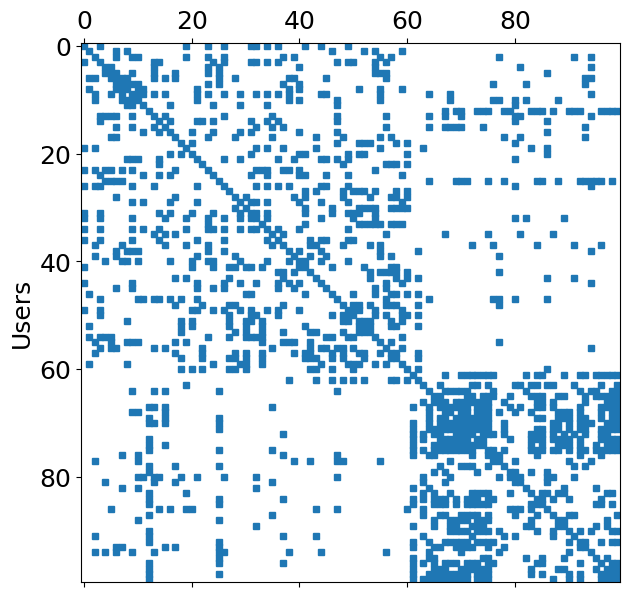

✅ Matrix is symmetric per rho 0.05
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.78e-04 nnz(S)/p=9.94e+01
* iter=1 time=2.50e-03 obj=5.83e+01 |delta(obj)|/obj=7.16e-01 nnz(X,L,W)/p=[9.94e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.50e-03 obj=3.79e+01 |delta(obj)|/obj=5.36e-01 nnz(X,L,W)/p=[9.94e+01 5.00e+01 9.30e+01] lns_iter=9 
* iter=3 time=3.

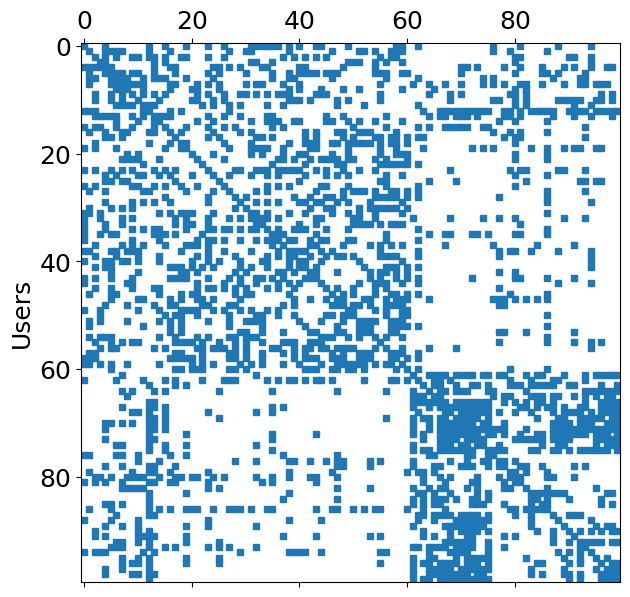

✅ Matrix is symmetric per rho 0.01
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.31e-04 nnz(S)/p=9.95e+01
* iter=1 time=2.43e-03 obj=5.81e+01 |delta(obj)|/obj=7.22e-01 nnz(X,L,W)/p=[9.95e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.68e-03 obj=3.77e+01 |delta(obj)|/obj=5.40e-01 nnz(X,L,W)/p=[9.95e+01 5.00e+01 9.30e+01] lns_iter=9 
* iter=3 time=3.

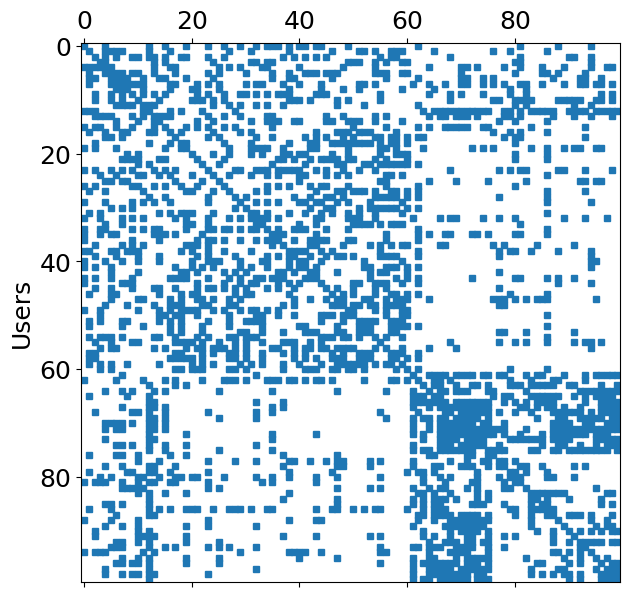

✅ Matrix is symmetric per rho 0.009
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.47e-04 nnz(S)/p=9.97e+01
* iter=1 time=2.73e-03 obj=5.72e+01 |delta(obj)|/obj=7.47e-01 nnz(X,L,W)/p=[9.97e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.88e-03 obj=3.67e+01 |delta(obj)|/obj=5.60e-01 nnz(X,L,W)/p=[9.97e+01 5.00e+01 9.30e+01] lns_iter=9 
* iter=3 time=2

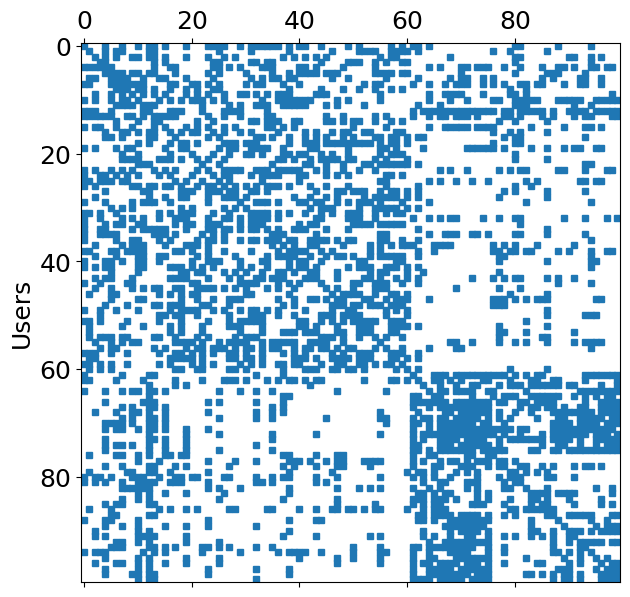

✅ Matrix is symmetric per rho 0.005
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.27e-04 nnz(S)/p=1.00e+02
* iter=1 time=2.47e-03 obj=5.64e+01 |delta(obj)|/obj=7.72e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.64e-03 obj=3.57e+01 |delta(obj)|/obj=5.81e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 9.31e+01] lns_iter=9 
* iter=3 time=2

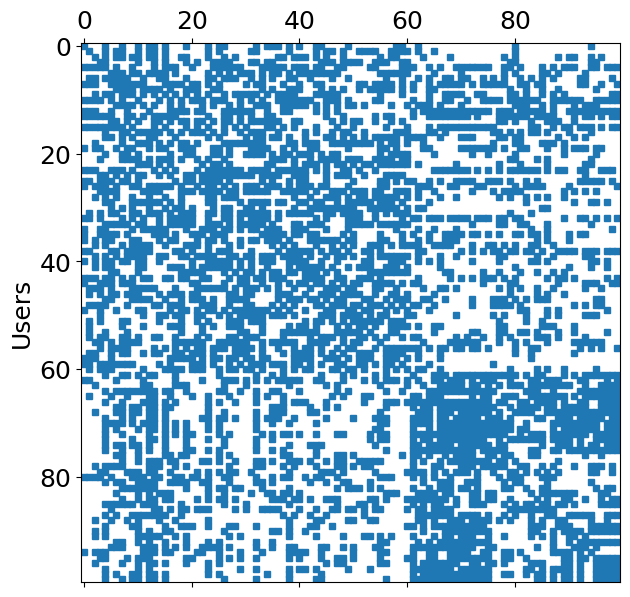

✅ Matrix is symmetric per rho 0.001
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-04 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.61e-04 nnz(S)/p=1.00e+02
* iter=1 time=2.43e-03 obj=5.62e+01 |delta(obj)|/obj=7.78e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.64e-03 obj=3.55e+01 |delta(obj)|/obj=5.86e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 9.31e+01] lns_iter=9 
* iter=3 time=3

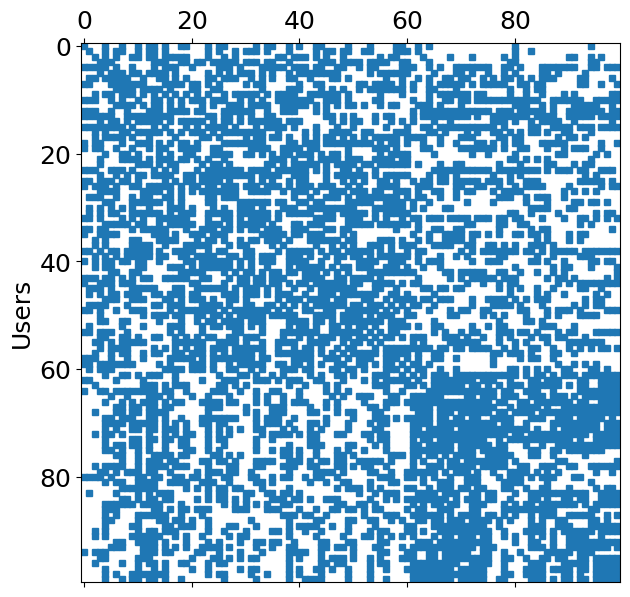

✅ Matrix is symmetric per rho 0.0001


In [38]:
data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    fit_norm_dict[rho], end_time = squic_fit(Y_new, lambda_val=rho, eta=rho * 0.1)
    end_time = round(end_time, 2)
    print(f"required time: {end_time}")

    nnz, nnz_r = nnz_fit(fit_norm_dict[rho], ROWS)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    sparsity_pattern(fit_norm_dict[rho])

    if is_symmetric(fit_norm_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append("Yes")
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append("No")

    data_nnz.append(nnz)
    data_nnzr.append(nnz_r)
    data_time.append(end_time)

table_fit_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]


# Table

In [39]:
def table(data, title, l):
    table = tabulate(
        data,
        headers=[title] + l,
        tablefmt="fancy_grid",
        numalign="center",
        stralign="center"
    )
    return table

In [40]:
print(table(table_squic, "SQUIC", l))

print(table(table_squic_norm, "SQUIC NORM", l))

print(table(table_fit, "SQUIC FIT", l))

print(table(table_fit_norm, "SQUIC FIT NORM", l))

╒═══════════╤═══════╤═══════╤═══════╤═══════╤════════╤════════╤════════╤═════════╤═════════╤═════════╕
│   SQUIC   │  0.9  │  0.5  │  0.2  │  0.1  │  0.09  │  0.05  │  0.01  │  0.009  │  0.005  │  0.001  │
╞═══════════╪═══════╪═══════╪═══════╪═══════╪════════╪════════╪════════╪═════════╪═════════╪═════════╡
│    NNZ    │ 7828  │ 6244  │ 5182  │ 4326  │  3646  │  3076  │  2632  │  2242   │  1938   │  1684   │
├───────────┼───────┼───────┼───────┼───────┼────────┼────────┼────────┼─────────┼─────────┼─────────┤
│  NNZ/Row  │ 78.28 │ 62.44 │ 51.82 │ 43.26 │ 36.46  │ 30.76  │ 26.32  │  22.42  │  19.38  │  16.84  │
├───────────┼───────┼───────┼───────┼───────┼────────┼────────┼────────┼─────────┼─────────┼─────────┤
│ Time (s)  │ 0.28  │ 0.13  │ 0.03  │ 0.04  │  0.05  │  0.02  │  0.04  │  0.02   │  0.02   │  0.02   │
├───────────┼───────┼───────┼───────┼───────┼────────┼────────┼────────┼─────────┼─────────┼─────────┤
│ Symmetric │  Yes  │  Yes  │  Yes  │  Yes  │  Yes   │  Yes   │  Yes   │ 

In [41]:
import networkx as nx
from sklearn.metrics import silhouette_score
from sklearn.cluster import SpectralClustering

In [42]:
l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2, 5e-2, 1e-2, 9e-3, 5e-3, 1e-3, 1e-4]

In [43]:
fit_norm_dict[rho]

matrix([[80.14253927,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        , 55.98466492,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        , 22.50298303, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [ 0.        ,  0.        ,  0.        , ..., 54.09713176,
         -0.35074695, -0.54068012],
        [ 0.        ,  0.        ,  0.        , ..., -0.35074695,
         54.47675057, -1.12179616],
        [ 0.        ,  0.        ,  0.        , ..., -0.54068012,
         -1.12179616, 54.17679564]])